In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
SEED = 42

df = pd.read_csv('db_pap3.csv')
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

Dimensiones: 10127 filas × 17 columnas


,clientnum,client_stayed,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_trans_amt,total_trans_ct
0,768805383,1,45,M,3,High School,Married,5833.333333333333,Blue,39,5,1,3,12691.0,777,1144,42
1,818770008,1,49,F,5,Graduate,Single,1666.6666666666667,Blue,44,6,1,2,8256.0,864,1291,33
2,713982108,1,51,M,3,Graduate,Married,8333.333333333334,Blue,36,4,1,0,3418.0,0,1887,20
3,769911858,1,40,F,4,High School,Unknown,1666.6666666666667,Blue,34,3,4,1,3313.0,2517,1171,20
4,709106358,1,40,M,3,Uneducated,Married,5833.333333333333,Blue,21,5,1,0,4716.0,0,816,28


In [9]:
df.tail(5)

,clientnum,client_stayed,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_trans_amt,total_trans_ct
10122,772366833,1,50,M,2,Graduate,Single,4166.666666666667,Blue,40,3,2,3,4003.0,1851,15476,117
10123,710638233,0,41,M,2,Unknown,Divorced,4166.666666666667,Blue,25,4,2,3,4277.0,2186,8764,69
10124,716506083,0,44,F,1,High School,Married,1666.6666666666667,Blue,36,5,3,4,5409.0,0,10291,60
10125,717406983,0,30,M,2,Graduate,Unknown,4166.666666666667,Blue,36,4,3,3,5281.0,0,8395,62
10126,714337233,0,43,F,2,Graduate,Married,1666.6666666666667,Silver,25,6,2,4,10388.0,1961,10294,61


In [2]:
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'n_unique': df.nunique(),
    'missing': df.isnull().sum(),
    'missing_%': (df.isnull().sum() / len(df) * 100).round(2)
})
info_df

,dtype,n_unique,missing,missing_%
clientnum,int64,10127,0,0.0
client_stayed,int64,2,0,0.0
customer_age,int64,45,0,0.0
gender,str,2,0,0.0
dependent_count,int64,6,0,0.0
education_level,str,7,0,0.0
marital_status,str,4,0,0.0
income_category,str,6,0,0.0
card_category,str,4,0,0.0
months_on_book,int64,44,0,0.0


In [3]:
df.describe().round(2)

,clientnum,client_stayed,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_trans_amt,total_trans_ct
count,1.012700e+04,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00
mean,7.391776e+08,0.84,46.33,2.35,35.93,3.81,2.34,2.46,8631.95,1162.81,4404.09,64.86
std,3.690378e+07,0.37,8.02,1.30,7.99,1.55,1.01,1.11,9088.78,814.99,3397.13,23.47
min,7.080821e+08,0.00,26.00,0.00,13.00,1.00,0.00,0.00,1438.30,0.00,510.00,10.00
25%,7.130368e+08,1.00,41.00,1.00,31.00,3.00,2.00,2.00,2555.00,359.00,2155.50,45.00
50%,7.179264e+08,1.00,46.00,2.00,36.00,4.00,2.00,2.00,4549.00,1276.00,3899.00,67.00
75%,7.731435e+08,1.00,52.00,3.00,40.00,5.00,3.00,3.00,11067.50,1784.00,4741.00,81.00
max,8.283431e+08,1.00,73.00,5.00,56.00,6.00,6.00,6.00,34516.00,2517.00,18484.00,139.00


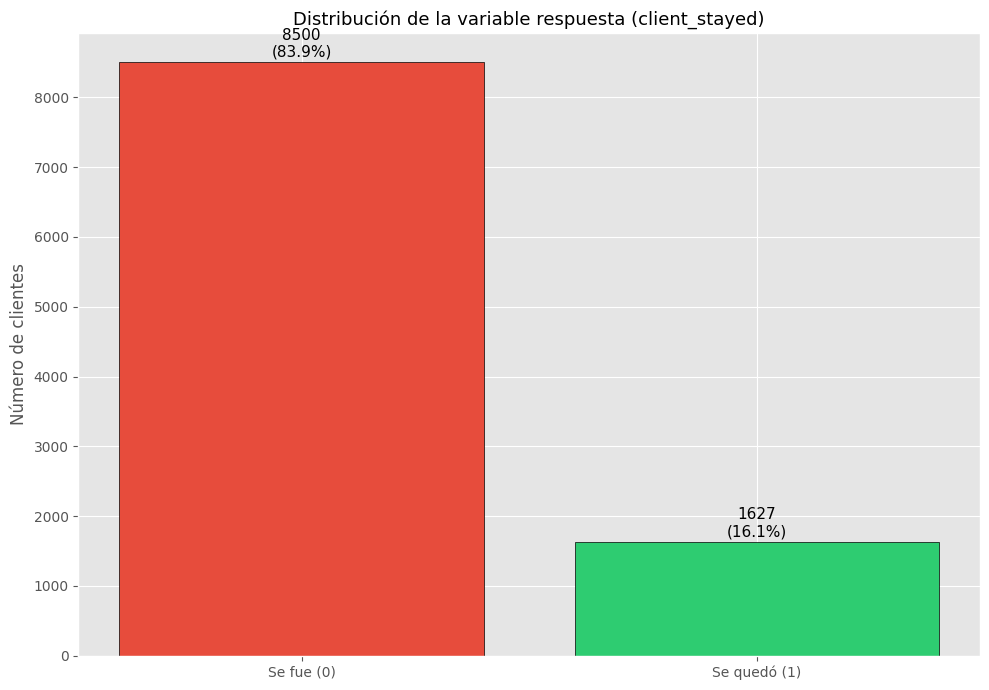

Ratio de churn: 16.1% abandona | 83.9% se queda


In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

counts = df['client_stayed'].value_counts()

bars = ax.bar(['Se fue (0)', 'Se quedó (1)'], counts.values, color=['#e74c3c','#2ecc71'], edgecolor='black')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11)
ax.set_title('Distribución de la variable respuesta (client_stayed)', fontsize=13)
ax.set_ylabel('Número de clientes')
plt.tight_layout()
plt.show()
print(f"Ratio de churn: {counts[0]/len(df)*100:.1f}% abandona | {counts[1]/len(df)*100:.1f}% se queda")

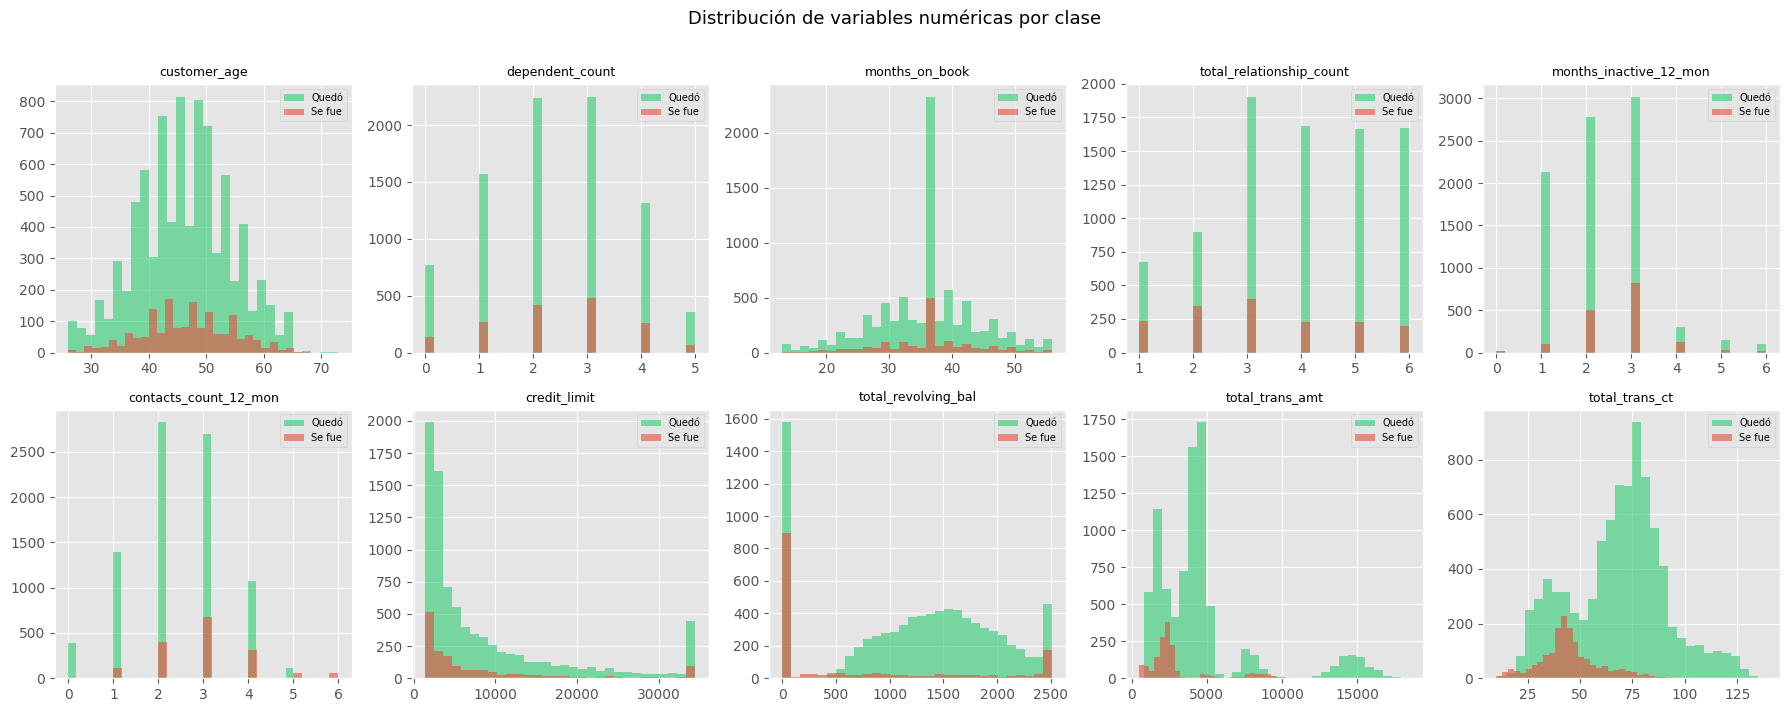

In [6]:
num_cols = ['customer_age','dependent_count','months_on_book','total_relationship_count',
            'months_inactive_12_mon','contacts_count_12_mon','credit_limit',
            'total_revolving_bal','total_trans_amt','total_trans_ct']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[df['client_stayed']==1][col], bins=30, alpha=0.6, color='#2ecc71', label='Quedó')
    axes[i].hist(df[df['client_stayed']==0][col], bins=30, alpha=0.6, color='#e74c3c', label='Se fue')
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('Distribución de variables numéricas por clase', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

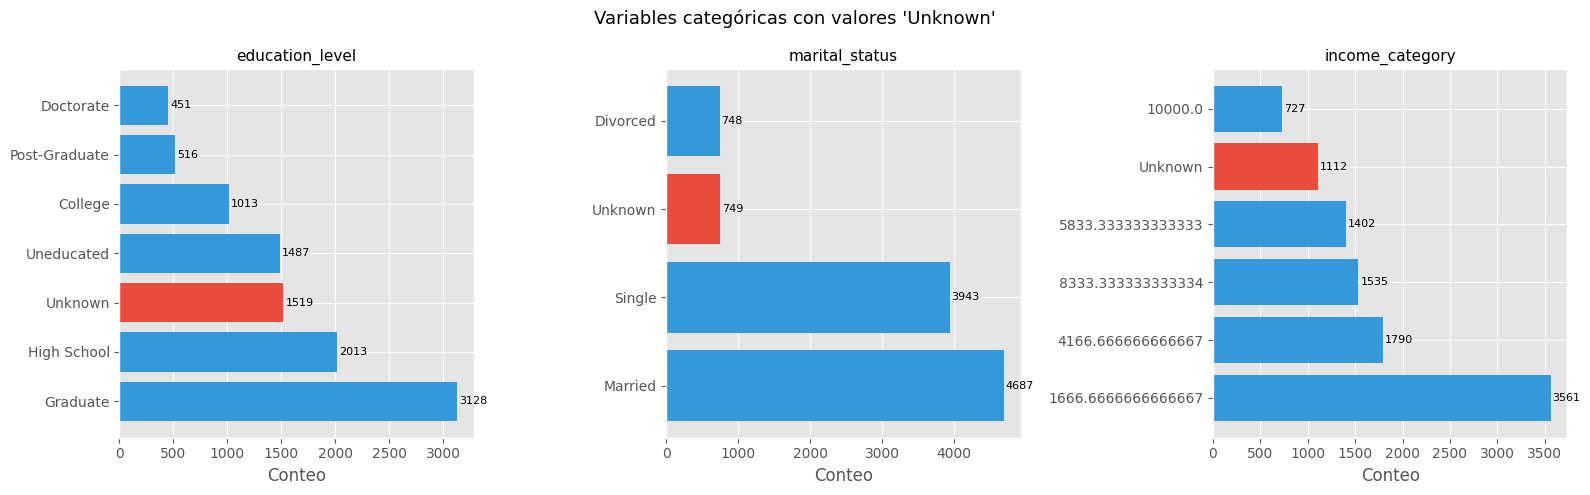

education_level: 15.0% Unknown
marital_status: 7.4% Unknown
income_category: 11.0% Unknown


In [7]:
cat_cols = ['education_level','marital_status','income_category','gender','card_category']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['education_level','marital_status','income_category']):
    vc = df[col].value_counts()
    colors = ['#e74c3c' if v == 'Unknown' else '#3498db' for v in vc.index]
    ax.barh(vc.index, vc.values, color=colors)
    ax.set_title(f'{col}', fontsize=11)
    ax.set_xlabel('Conteo')
    for j, v in enumerate(vc.values):
        ax.text(v + 20, j, str(v), va='center', fontsize=8)

plt.suptitle("Variables categóricas con valores 'Unknown'", fontsize=13)
plt.tight_layout()
plt.show()

# Porcentajes Unknown
for col in ['education_level','marital_status','income_category']:
    pct = (df[col] == 'Unknown').mean() * 100
    print(f"{col}: {pct:.1f}% Unknown")

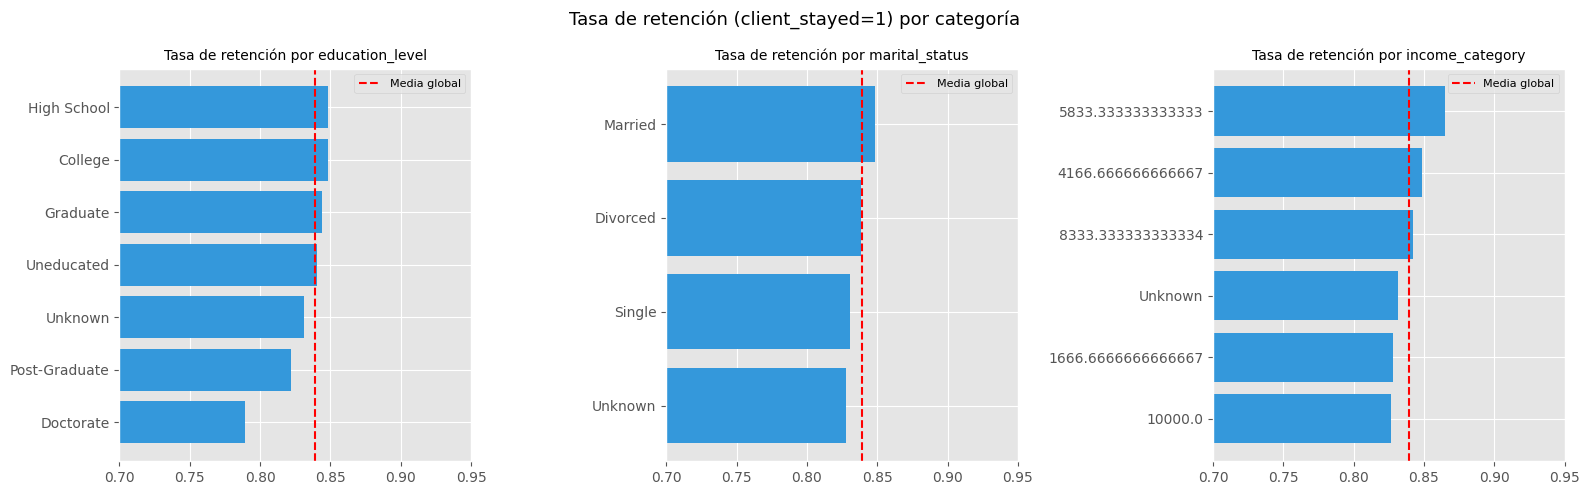

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['education_level','marital_status','income_category']):
    retention = df.groupby(col)['client_stayed'].mean().sort_values()
    ax.barh(retention.index, retention.values, color='#3498db')
    ax.axvline(df['client_stayed'].mean(), color='red', linestyle='--', label='Media global')
    ax.set_title(f'Tasa de retención por {col}', fontsize=10)
    ax.set_xlim(0.7, 0.95)
    ax.legend(fontsize=8)

plt.suptitle("Tasa de retención (client_stayed=1) por categoría", fontsize=13)
plt.tight_layout()
plt.show()